# VR Dedup dev
Goals:
- identify flash img dataset 
- Identify clear dups from vision
- use and understand dedupblock
- Use Bella's merger function

In [1]:
import retinanalysis as ra
import numpy as np
import matplotlib.pyplot as plt
print(ra.settings.mea_config)

[2025-09-30 15:38:01,757][INFO]: DataJoint 0.14.4 connected to root@127.0.0.1:3306


{'data': '/Volumes/Vyom MEA/analysis', 'raw': '/Volumes/Vyom MEA/data/raw', 'analysis': '/Volumes/Vyom MEA/analysis', 'h5': '/Volumes/Vyom MEA/data/samarjit_datajoint/data_dirs/data', 'meta': '/Volumes/Vyom MEA/data/samarjit_datajoint/data_dirs/meta', 'tags': '/Volumes/Vyom MEA/data/samarjit_datajoint/data_dirs/tags', 'query': '/Volumes/data-1/analysis', 'user': 'vyomr'}


In [2]:
df_q = ra.get_datasets_from_protocol_names('presentimages')
df_q['folders'] = ''
# Populate folders column from epoch block params
for i, row in df_q.iterrows():
    eb_q = ra.schema.EpochBlock() & f'id={row["block_id"]}'
    d_eb = eb_q.fetch(format='frame').reset_index().at[0, 'parameters']
    if 'fileFolder' in d_eb:
        str_folder = d_eb['fileFolder']
    elif 'fileFolders' in d_eb:
        str_folder = d_eb['fileFolders']
    else:
        print(f'No fileFolder(s) in epoch block {row["block_id"]}')
        continue
    df_q.at[i, 'folders'] = str_folder


Found 1 protocols matching "presentimages":
['manookinlab.protocols.PresentImages']

Found 33 experiments, 108 epoch blocks.



In [11]:
# Keep rows with folders containing 'ImageNet'
df_q = df_q[df_q['folders'].str.contains('ImageNet', na=False)]
# And NDF <= 0.5
df_q = df_q[df_q['NDF'] <= 0.5]
df_q

,exp_name,datafile_name,NDF,chunk_name,protocol_name,is_mea,data_dir,group_label,experiment_id,protocol_id,group_id,block_id,chunk_id,folders
70,20250212C,data012,0.0,images,manookinlab.protocols.PresentImages,1,20250212C/data012,natural image flash 168 R*/rod 0.5 mean,114,16,2088,3044,417,ImageNetTest
71,20250219C,data006,0.0,images,manookinlab.protocols.PresentImages,1,20250219C/data006,flashed natural images,115,16,2094,3055,420,ImageNetTest
72,20250219C,data014,0.0,images,manookinlab.protocols.PresentImages,1,20250219C/data014,flashed natural images,115,16,2100,3063,420,"ImageNet02,ImageNet03"
73,20250219C,data015,0.0,images,manookinlab.protocols.PresentImages,1,20250219C/data015,flashed natural images,115,16,2100,3064,420,"ImageNet04,ImageNet05"
77,20250219H,data010,0.0,images,manookinlab.protocols.PresentImages,1,20250219H/data010,flashed images,116,16,2115,3079,431,"ImageNet01,ImageNetTest"
78,20250219H,data020,0.0,images,manookinlab.protocols.PresentImages,1,20250219H/data020,flashed images,116,16,2118,3084,431,"ImageNet02,ImageNet03"
79,20250306H,data007,0.0,doves_images,manookinlab.protocols.PresentImages,1,20250306H/data007,flashed images 45k R*,118,16,2136,3108,448,"ImageNet01,ImageNetTest"
80,20250306H,data008,0.0,doves_images,manookinlab.protocols.PresentImages,1,20250306H/data008,flashed images 45k R*,118,16,2136,3109,448,ImageNet07
84,20250306C,data023,0.0,doves_images,manookinlab.protocols.PresentImages,1,20250306C/data023,natural image flash ndf 0,119,16,2170,3157,453,"ImageNet01,ImageNetTest"
85,20250306C,data026,0.0,doves_images,manookinlab.protocols.PresentImages,1,20250306C/data026,natural image flash ndf 0,119,16,2170,3158,453,"ImageNet01,ImageNetTest"


Finding typing files for unique experiments:   0%|          | 0/8 [00:00<?, ?it/s]

Found 2 datasets without any typing files:


,exp_name,datafile_name,chunk,nearest_noise_chunk,nearest_noise_distance
0,20250306H,data007,doves_images,chunk2,33.933333
1,20250306H,data008,doves_images,chunk2,44.466667


Found 51 datasets with typing files.
Found 9 unique datasets with typing files and > 0  cells of interest.
Error processing 20250212C, ['data012'], chunk2, kilosort2.5, SN_kilosort2.5.classification.txt: 
Error processing 20250219C, ['data006'], chunk1, kilosort2.5, kilosort2.5.classification.txt: 
Error processing 20250219C, ['data014' 'data015'], chunk2, kilosort2.5, kilosort2.5.classification.txt: 'kilosort2.5.classification.txt' is not in list
Error processing 20250219H, ['data010'], chunk2, kilosort2.5, kilosort2.5.classification.txt: 
Error processing 20250219H, ['data020'], chunk3, kilosort2.5, kilosort2.5.classification.txt: 
Error processing 20250429C, ['data008' 'data013'], chunk2, kilosort2.5, dragos_kilosort2.5.classification.txt: 
Error processing 20250911C, ['data007' 'data008' 'data009' 'data001' 'data002' 'data003'], chunk2, kilosort2.5, dragos_kilosort2.5.classification.txt: 


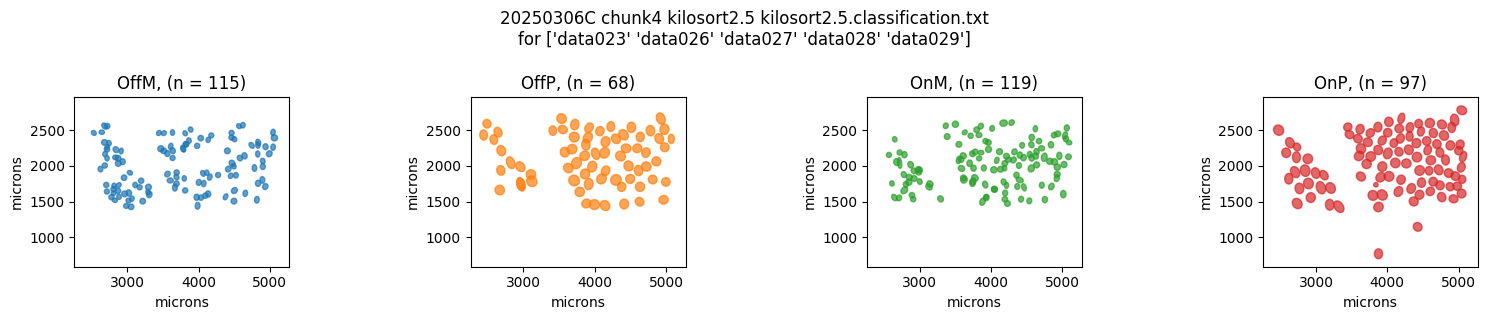

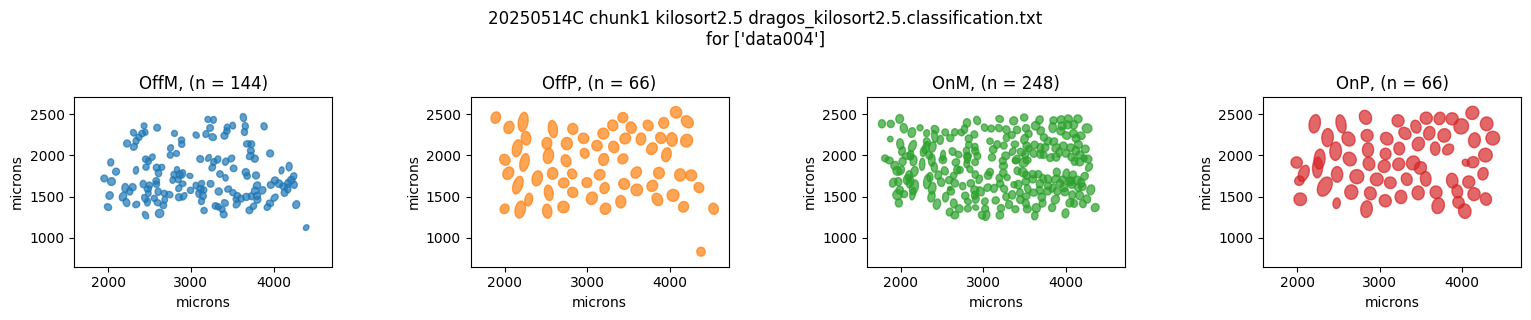

In [12]:
ls_cell_types = ['OffP', 'OffM', 'OnP', 'OnM']

# Plot top 5 datasets according to the highest number of cells
# of interest (sum of # cells of given types)
df_typed, df_not_typed = ra.plot_mosaics_for_all_datasets(df_q, ls_cell_types, n_top=10)

## 20250306C

In [3]:
exp_name = '20250306C'
ra.get_exp_summary(exp_name)

,exp_name,prep_label,datafile_name,group_label,NDF,chunk_name,protocol_name,duration_minutes,minutes_since_start,start_time,end_time,data_dir,experiment_id,prep_id,group_id,block_id,chunk_id,protocol_id
0,20250306C,20250306Cm1,data000,CRF,0.0,chunk1,manookinlab.protocols.ContrastResponseGrating,1.22,1.22,2025-03-06 10:32:10,2025-03-06 10:33:23,20250306C/data000,119,136,2155,3136,459,1
1,20250306C,20250306Cm1,data001,CRF,0.0,chunk1,manookinlab.protocols.ContrastResponseGrating,1.23,4.37,2025-03-06 10:35:18,2025-03-06 10:36:32,20250306C/data001,119,136,2155,3137,459,1
2,20250306C,20250306Cm1,data002,noise,0.0,chunk1,manookinlab.protocols.SpatialNoise,12.52,18.22,2025-03-06 10:37:52,2025-03-06 10:50:23,20250306C/data002,119,136,2156,3138,459,19
3,20250306C,20250306Cm1,data003,noise,0.0,chunk1,manookinlab.protocols.SpatialNoise,49.50,68.97,2025-03-06 10:51:38,2025-03-06 11:41:08,20250306C/data003,119,136,2156,3139,459,19
4,20250306C,20250306Cm1,data005,big noise,0.0,big_noise,manookinlab.protocols.SpatialNoise,30.98,105.78,2025-03-06 11:46:58,2025-03-06 12:17:57,20250306C/data005,119,136,2157,3140,458,19
5,20250306C,20250306Cm1,data006,CRF grid,0.5,crf_grid,edu.washington.riekelab.vyom.protocols.Contras...,28.87,144.17,2025-03-06 12:27:28,2025-03-06 12:56:20,20250306C/data006,119,136,2158,3141,452,66
6,20250306C,20250306Cm1,data007,crf 4 R*,1.0,chunk2,manookinlab.protocols.ContrastResponseGrating,1.17,192.02,2025-03-06 13:43:01,2025-03-06 13:44:11,20250306C/data007,119,136,2159,3142,461,1
7,20250306C,20250306Cm1,data008,spatial noise 4 R*,1.0,chunk2,manookinlab.protocols.SpatialNoise,8.82,222.35,2025-03-06 14:05:42,2025-03-06 14:14:31,20250306C/data008,119,136,2160,3143,461,19
8,20250306C,20250306Cm1,data009,crf 4R*,1.0,chunk2,manookinlab.protocols.ContrastResponseGrating,1.22,225.30,2025-03-06 14:16:15,2025-03-06 14:17:28,20250306C/data009,119,136,2161,3144,461,1
9,20250306C,20250306Cm1,data010,spatial noise 10k R*,0.5,chunk2,manookinlab.protocols.SpatialNoise,29.52,270.15,2025-03-06 14:32:48,2025-03-06 15:02:19,20250306C/data010,119,136,2162,3145,461,19


Want to dedup chunks doves_images (data023,daata026,data027,data028,data029) and chunk4 (data020, data021)

Ig lets start with data021 for the noise run

In [4]:
import sys
sys.path.append('/Users/riekelabbackup/Desktop/Vyom/RetinAnalysis/src/retinanalysis/classes/')
import dedup as dd
import importlib
importlib.reload(dd)

<module 'dedup' from '/Users/riekelabbackup/Desktop/Vyom/RetinAnalysis/src/retinanalysis/classes/dedup.py'>

Loading VCD from /Volumes/Vyom MEA/analysis/20250306C/chunk4/kilosort2.5 ...
VCD loaded with 534 cells.

Loaded spatial maps for channels [0, 2] and 534 cells of shape (127, 203, 2)
Spatial maps have been padded to align with RF parameters.

Creating deduplication sets...
Loading Kilosort amplitudes...


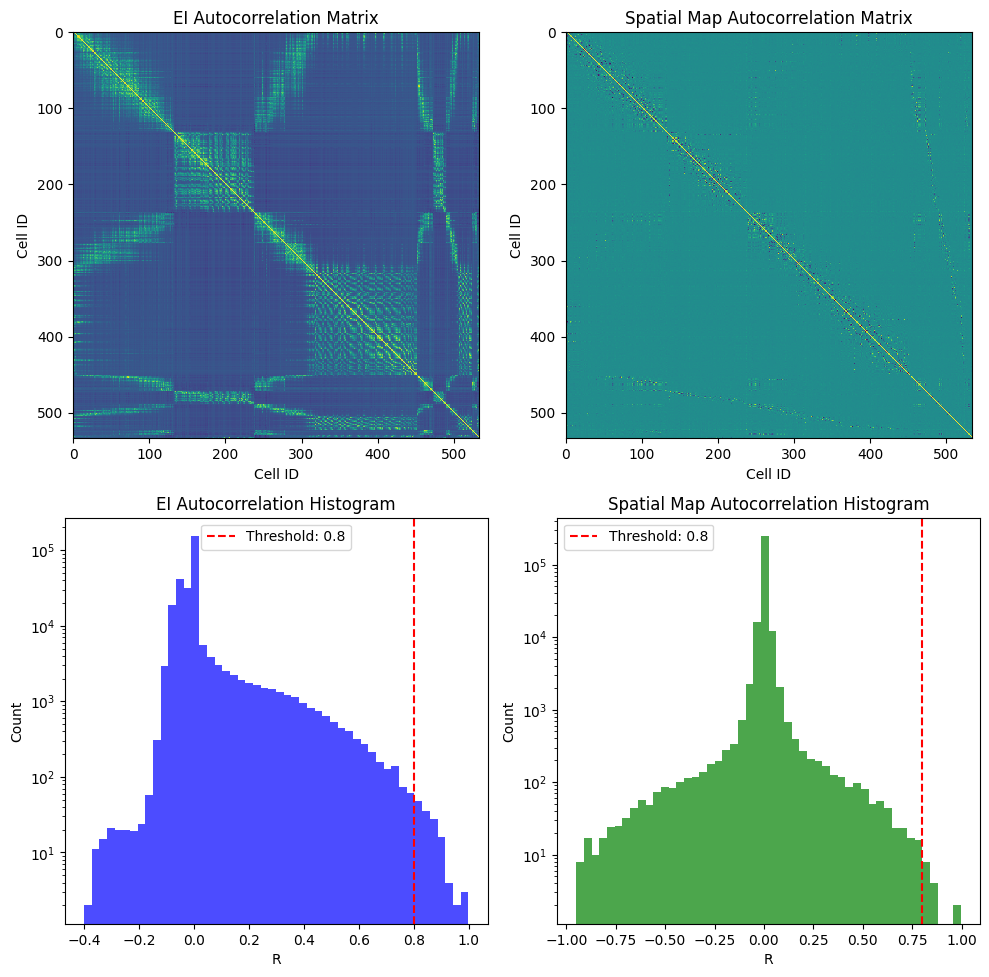

In [5]:
#plot ei autocorrelation, and spatial map autocorr if available
datafile_name = 'data021'
chunk_name = 'chunk4'
dd_block = dd.DedupBlock(exp_name, datafile_name, chunk_name = chunk_name, is_noise = True,
                         ei_method='space', ei_threshold=0.8, sm_threshold=0.8)
dd_block.plot_correlations();

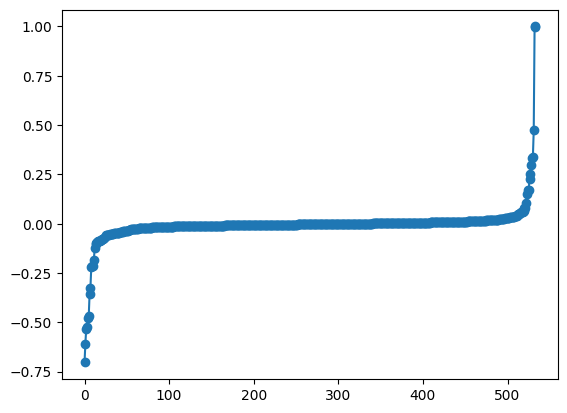

In [6]:
cell_id = 201
cell_idx = dd_block.cluster_to_index[cell_id]
# ei_r = dd_block.ei_autocorr[cell_idx]
# plt.plot(np.sort(ei_r), '-o')
sm_r = dd_block.sm_autocorr[cell_idx]
plt.plot(np.sort(sm_r), '-o')

In [7]:
#generate dataframe for all pairwise metrics for above-threshold clusters (in either ei or sm category)
#extended_pairs is a set of tuples of transitively related cells in the above-threshold correlation pairs
summary_stats = dd_block.get_summary_stats(dd_block.dedup_sets['both_pairs'])
summary_stats

,cluster_a,cluster_b,ei_corr,sm_corr,overlap_fraction
0,105,692,0.987429,0.849433,0.916679
1,246,248,0.808180,0.800612,0.102832
2,201,288,0.997692,0.996192,0.080120
3,104,693,0.969203,0.807496,0.995980
4,407,426,0.837495,0.977985,0.681160


In [8]:
dd_block.amplitudes.shape

(3, 25106044)

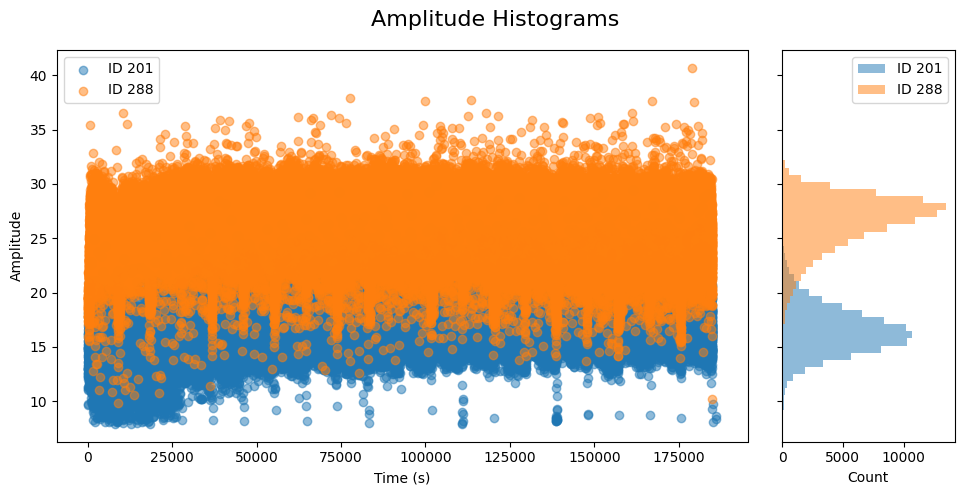

In [9]:
#if we wanted to, we could just plot everything! (if detailed=True, plots timecourse of top electrodes)
#TODO: do we want this to be the default behavior? probably not - pull out best pairs to visualize?
#TODO: check marginal histograms for gaussian violations? to check if bimodal / needs splitting?
extended_pairs = ra.dedup.generate_extended_pairings(dd_block.dedup_sets['both_pairs'])
for pair in extended_pairs:
    pair = (201, 288)
    # dd_block.visualize_groups(pair);
    dd_block.plot_amplitude_histograms(pair);
    break

TODO: load templates.npy and dev plot for template waveform

Expect to see distinct groups of electrodes

## Bella merger function

In [10]:
1.5*1e-3*2e4

30.0

In [12]:
import merge
import importlib
importlib.reload(merge)

<module 'merge' from '/Users/riekelabbackup/Desktop/Vyom/RetinAnalysis/nbs/merge.py'>

In [13]:
# merge_ids = [201, 288]
merge_ids = {201: [288]}
cchs, delays = merge.get_cchs(merge_ids, dd_block.AnalysisChunk.vcd)

Calculating CCHs


100%|██████████| 20/20 [00:00<00:00, 38818.18it/s]


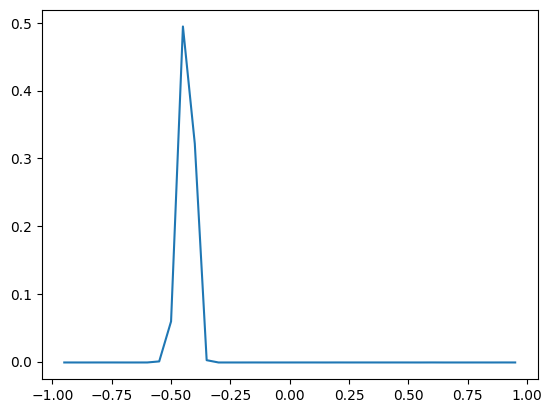

In [14]:
plt.plot(delays/20000*1e3, cchs[201][0])

In [25]:
importlib.reload(merge)
df_st = merge.merge_spikes_for_unit(201, [201, 288], cchs, delays, dd_block.AnalysisChunk.vcd)
df_st

hi


,original_unit,original_spike_time,adjusted_spike_time,unique,valid,shared,spike_id
0,201,58552,58552,True,True,True,0
1,288,58544,58553,False,True,True,0
2,288,58599,58608,True,True,False,1
3,288,58996,59005,True,True,False,2
4,201,60801,60801,True,True,True,3
...,...,...,...,...,...,...,...
183362,288,73990445,73990454,True,True,False,102799
183363,201,74064128,74064128,True,True,False,102800
183364,201,74103336,74103336,True,True,False,102801
183365,201,74415143,74415143,True,True,False,102802


In [28]:
df_st['shared'].value_counts()

shared
True     161070
False     22297
Name: count, dtype: int64

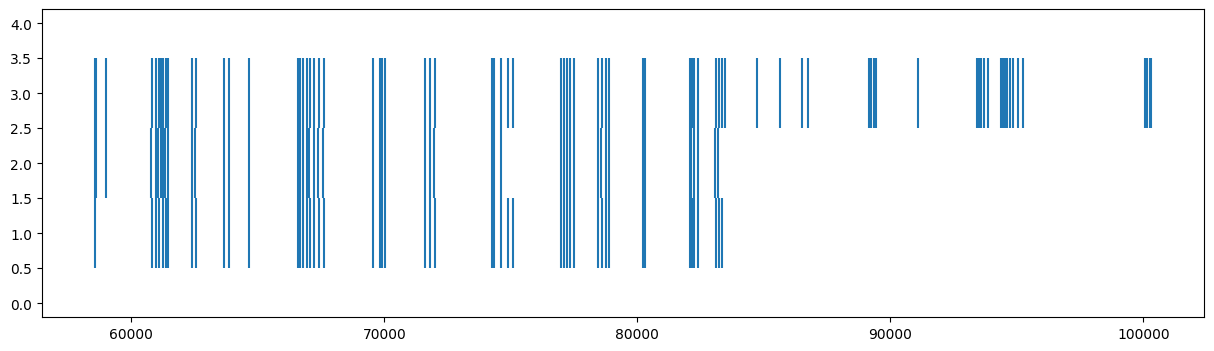

In [31]:
vcd = dd_block.AnalysisChunk.vcd
plt.figure(figsize=(15,4))
plt.eventplot(vcd.get_spike_times_for_cell(201)[:50], lineoffsets=1)
plt.eventplot(vcd.get_spike_times_for_cell(288)[:50], lineoffsets=2)
plt.eventplot(df_st.loc[df_st.unique, 'adjusted_spike_time'][:80], lineoffsets=3)